# Open-Source Ecosystem Intelligence
## Adoption, Community Participation, Maintenance Workload, and Repository Health

This notebook analyzes a snapshot of prominent GitHub repositories to answer one central question:

> **What distinguishes highly visible, fast-adopting, community-oriented, and sustainably maintained open-source projects?**

Rather than treating stars as a complete measure of success, the analysis separates four dimensions:

1. **Historical visibility** — accumulated stars.
2. **Lifetime adoption velocity** — average stars acquired per month over the project's lifetime.
3. **Community participation proxy** — forks relative to stars.
4. **Maintenance workload proxy** — open issues relative to stars and repository recency.



## 1. Setup and data loading

In [12]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["figure.dpi"] = 110


def resolve_data_path(filename="github_projects_transformed.csv"):
    """Return the first existing dataset path from common project layouts."""
    candidates = [
        Path("data/processed") / filename,
        Path("../data/processed") / filename,
        Path(filename),
        Path("/mnt/data") / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    searched = "\n".join(f"- {path}" for path in candidates)
    raise FileNotFoundError(
        f"Could not locate {filename}. Searched:\n{searched}"
    )


DATA_PATH = resolve_data_path()
df_raw = pd.read_csv(DATA_PATH)

print(f"Loaded {len(df_raw):,} projects from: {DATA_PATH}")
print(f"Columns available: {len(df_raw.columns)}")
display(df_raw.head(10))

Loaded 73 projects from: C:\Users\USB\Desktop\open-source-analytics\data\processed\github_projects_transformed.csv
Columns available: 19


,full_name,name,url,description,language,stars,forks,watchers,open_issues,created_at,last_commit_at,days_active,days_since_commit,stars_per_month,is_abandoned,activity_level,project_maturity,popularity_score,data_collected_at
0,react/react,react,https://github.com/react/react,The library for web and native user interfaces.,JavaScript,246957,51183,246957,1247,2013-05-24T16:15:54Z,2026-08-04T16:30:52Z,4820,0,"1,527.57",False,Very Active,Mature,"188,224.80",2026-08-04 20:39:21.795662
1,vuejs/vue,vue,https://github.com/vuejs/vue,"This is the repo for Vue 2. For Vue 3, go to h...",TypeScript,210192,33774,210192,637,2013-07-29T03:24:51Z,2024-10-10T07:24:15Z,4754,663,"1,318.09",True,Abandoned,Mature,"157,266.60",2026-08-04 20:39:21.795662
2,angular/angular,angular,https://github.com/angular/angular,Deliver web apps with confidence 🚀,TypeScript,100825,27401,100825,1147,2014-09-18T16:12:01Z,2026-08-04T18:51:28Z,4338,0,692.48,False,Very Active,Mature,"78,797.80",2026-08-04 20:39:21.795662
3,sveltejs/svelte,svelte,https://github.com/sveltejs/svelte,web development for the rest of us,JavaScript,87860,5176,87860,1116,2016-11-20T18:13:05Z,2026-08-02T08:37:26Z,3544,2,737.49,False,Very Active,Mature,"63,054.80",2026-08-04 20:39:21.795662
4,vercel/next.js,next.js,https://github.com/vercel/next.js,The React Framework,JavaScript,141358,31678,141358,4314,2016-10-05T23:32:51Z,2026-08-05T00:28:28Z,3590,-1,"1,171.48",False,Very Active,Mature,"108,454.00",2026-08-04 20:39:21.795662
5,remix-run/remix,remix,https://github.com/remix-run/remix,"Build Better Websites. Create modern, resilien...",TypeScript,33280,2790,33280,65,2020-10-26T19:57:28Z,2026-08-04T19:17:30Z,2108,0,466.98,False,Very Active,Mature,"24,133.00",2026-08-04 20:39:21.795662
6,nuxt/nuxt,nuxt,https://github.com/nuxt/nuxt,the full-stack Vue framework,TypeScript,60724,5780,60724,538,2016-10-26T11:18:47Z,2026-08-04T21:53:52Z,3569,0,506.17,False,Very Active,Mature,"44,240.80",2026-08-04 20:39:21.795662
7,withastro/astro,astro,https://github.com/withastro/astro,The web framework for content-driven websites....,TypeScript,61542,3682,61542,112,2021-03-15T17:19:47Z,2026-08-04T23:58:40Z,1968,0,924.05,False,Very Active,Mature,"44,184.00",2026-08-04 20:39:21.795662
8,QwikDev/qwik,qwik,https://github.com/QwikDev/qwik,"Instant-loading web apps, without effort",TypeScript,22037,1395,22037,161,2021-05-19T15:33:32Z,2026-08-04T21:14:32Z,1903,0,342.01,False,Very Active,Mature,"15,844.40",2026-08-04 20:39:21.795662
9,solidjs/solid,solid,https://github.com/solidjs/solid,"A declarative, efficient, and flexible JavaScr...",TypeScript,35795,1086,35795,29,2018-04-24T16:36:27Z,2026-08-05T00:03:24Z,3024,-1,351.62,False,Very Active,Mature,"25,382.30",2026-08-04 20:39:21.795662


## 2. Data-quality audit and corrected metric definitions

Before interpreting the data, the notebook checks for fields that are duplicated, constant, imbalanced, or potentially misleading.



In [13]:
required_columns = {
    "full_name", "language", "stars", "forks", "watchers", "open_issues",
    "created_at", "last_commit_at", "days_active", "days_since_commit",
    "stars_per_month", "is_abandoned", "activity_level", "project_maturity",
    "popularity_score", "data_collected_at"
}
missing_columns = sorted(required_columns.difference(df_raw.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# Work on a copy so the original snapshot remains unchanged.
df = df_raw.copy()

# Normalize dates to one timezone.
for column in ["created_at", "last_commit_at", "data_collected_at"]:
    df[column] = pd.to_datetime(df[column], errors="coerce", utc=True)

# Basic cleaning.
df["language"] = df["language"].fillna("Unknown")
df["stars"] = pd.to_numeric(df["stars"], errors="coerce").fillna(0)
df["forks"] = pd.to_numeric(df["forks"], errors="coerce").fillna(0)
df["open_issues"] = pd.to_numeric(df["open_issues"], errors="coerce").fillna(0)

# Recalculate time-based fields using normalized timestamps.
df["days_active_clean"] = (
    (df["data_collected_at"] - df["created_at"]).dt.total_seconds() / 86_400
).clip(lower=1)

df["days_since_commit_clean"] = (
    (df["data_collected_at"] - df["last_commit_at"]).dt.total_seconds() / 86_400
).clip(lower=0)

# Corrected analytical metrics.
AVERAGE_DAYS_PER_MONTH = 365.25 / 12
df["lifetime_star_velocity"] = (
    df["stars"] / (df["days_active_clean"] / AVERAGE_DAYS_PER_MONTH)
)
df["forks_per_1k_stars"] = np.where(
    df["stars"] > 0, df["forks"] / df["stars"] * 1_000, np.nan
)
df["issues_per_1k_stars"] = np.where(
    df["stars"] > 0, df["open_issues"] / df["stars"] * 1_000, np.nan
)
df["project_age_years"] = df["days_active_clean"] / 365.25

watchers_duplicate_stars = df["watchers"].equals(df["stars"].astype(df["watchers"].dtype))
popularity_star_corr = df["popularity_score"].corr(df["stars"])

quality_audit = pd.DataFrame({
    "Check": [
        "Rows in snapshot",
        "Languages represented",
        "Missing language values after cleaning",
        "Raw negative days_since_commit values",
        "Watchers exactly duplicate stars",
        "Unique project_maturity categories",
        "Popularity score correlation with stars",
        "Activity-level categories",
    ],
    "Result": [
        f"{len(df):,}",
        f"{df['language'].nunique():,}",
        f"{df['language'].isna().sum():,}",
        f"{(df_raw['days_since_commit'] < 0).sum():,}",
        str(watchers_duplicate_stars),
        f"{df['project_maturity'].nunique():,}",
        f"{popularity_star_corr:.3f}",
        ", ".join(f"{k}: {v}" for k, v in df["activity_level"].value_counts().items()),
    ]
})

display(quality_audit)

,Check,Result
0,Rows in snapshot,73
1,Languages represented,14
2,Missing language values after cleaning,0
3,Raw negative days_since_commit values,12
4,Watchers exactly duplicate stars,True
5,Unique project_maturity categories,1
6,Popularity score correlation with stars,0.998
7,Activity-level categories,"Very Active: 70, Abandoned: 2, Moderately Acti..."


### Decisions applied

- **`watchers` is excluded from scoring** because it duplicates `stars` throughout this snapshot.
- **`project_maturity` is not used for segmentation** because every project is classified as `Mature`.
- **`popularity_score` is not used as an independent insight** because it is constructed primarily from stars and forks and is almost perfectly correlated with stars.
- Negative `days_since_commit` values are corrected by recalculating the difference from normalized timestamps and clipping small timezone-related negatives to zero.
- **`stars_per_month` is renamed and recalculated as `lifetime_star_velocity`**. It is a lifetime average—not recent growth.

## 3. Executive snapshot

In [3]:
collection_date = df["data_collected_at"].max().date()
median_stars = df["stars"].median()
median_velocity = df["lifetime_star_velocity"].median()

snapshot = pd.DataFrame({
    "Metric": [
        "Collection date",
        "Projects",
        "Languages",
        "Total stars",
        "Total forks",
        "Open issues",
        "Median stars per project",
        "Median lifetime stars per month",
        "Abandoned repositories",
    ],
    "Value": [
        str(collection_date),
        f"{len(df):,}",
        f"{df['language'].nunique():,}",
        f"{df['stars'].sum():,.0f}",
        f"{df['forks'].sum():,.0f}",
        f"{df['open_issues'].sum():,.0f}",
        f"{median_stars:,.0f}",
        f"{median_velocity:,.1f}",
        f"{df['is_abandoned'].sum():,.0f}",
    ]
})
display(snapshot)

,Metric,Value
0,Collection date,2026-08-04
1,Projects,73
2,Languages,14
3,Total stars,"4,387,238"
4,Total forks,"1,057,136"
5,Open issues,"138,152"
6,Median stars per project,"45,463"
7,Median lifetime stars per month,331.8
8,Abandoned repositories,2


# Analytical story

The remainder of the notebook follows a connected sequence:

1. Which language ecosystems dominate the sample?
2. How concentrated is repository attention?
3. Which projects are leaders, challengers, established repositories, or niche projects?
4. Which repositories show unusually strong fork participation?
5. Which repositories carry unusually high issue workloads or retain legacy influence despite inactivity?
6. Does project age explain popularity?

## 4. Insight 1 - Language ecosystem breadth and visibility

Total stars identify broad ecosystem visibility, but totals naturally favor languages represented by more repositories. The analysis therefore compares project count, total stars, median stars, and median lifetime velocity.

,language,projects,total_stars,median_stars,total_forks,median_lifetime_velocity,median_forks_per_1k_stars
7,Python,24,1146260,"37,966.00",316871,257.30,275.20
6,JavaScript,9,811716,"69,314.00",174478,346.30,207.30
12,TypeScript,10,707685,"61,117.50",106341,499.20,103.30
4,Go,11,655666,"52,069.00",131041,332.20,191.90
2,C++,4,344707,"67,769.00",148470,429.60,367.30
0,C,2,263376,"131,688.00",69575,732.10,266.20
9,Rust,2,139960,"69,980.00",17246,414.20,104.60
8,Ruby,4,102020,"17,714.50",31480,89.30,292.80
11,Swift,1,70217,"70,217.00",10786,542.70,153.60
10,Scala,1,43783,"43,783.00",29307,293.30,669.40


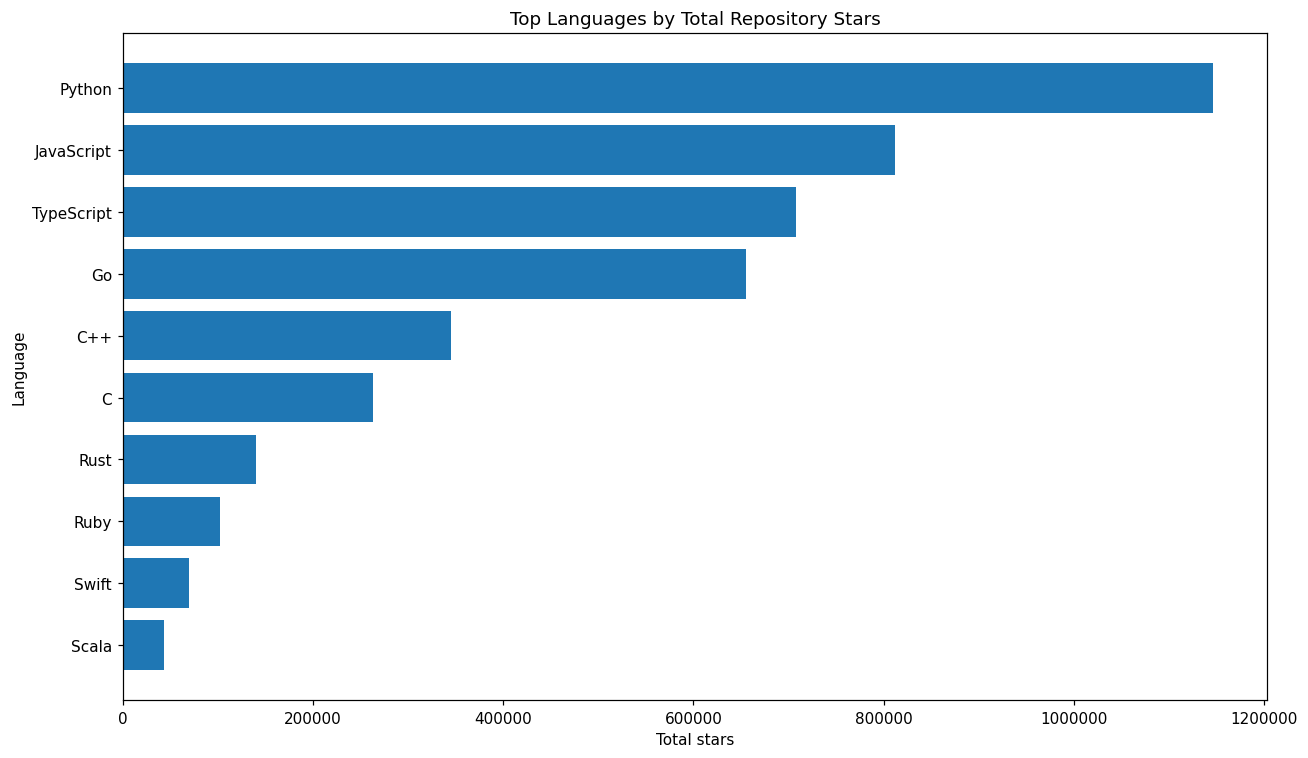

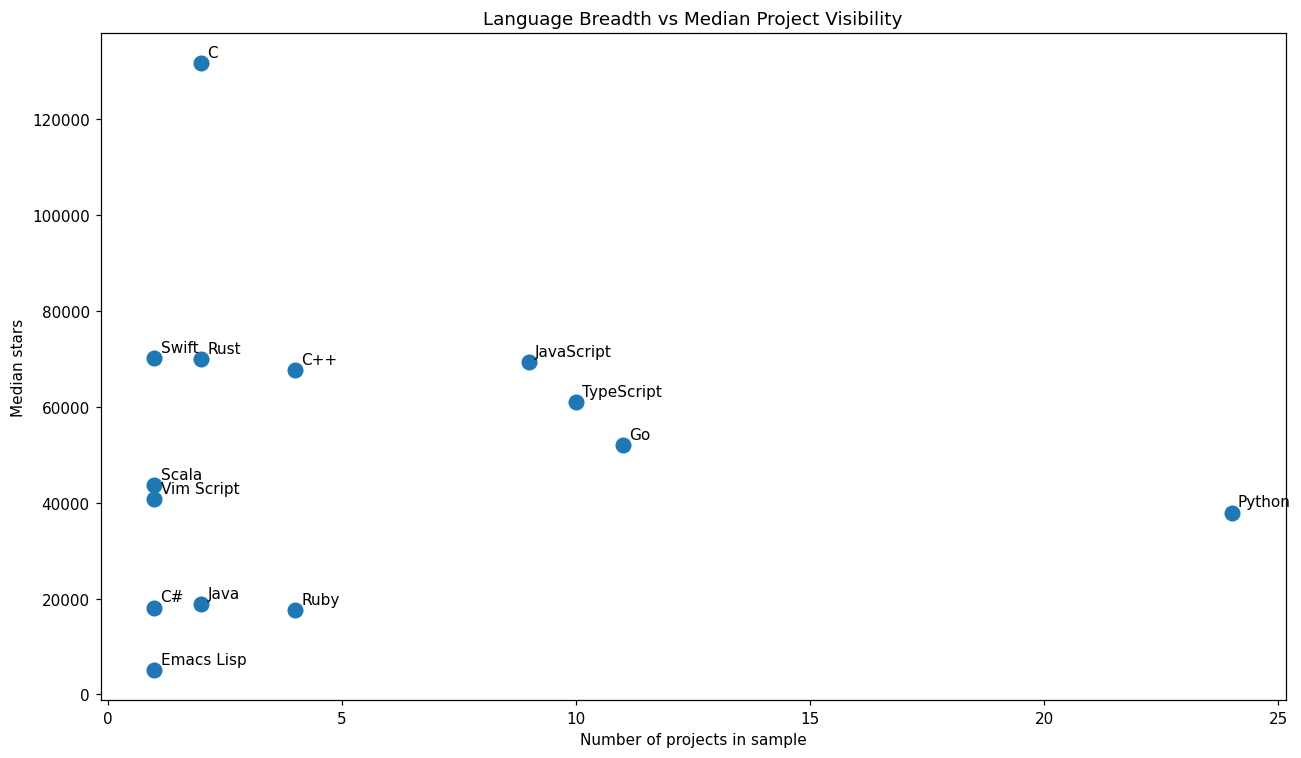


### Finding

- **Python** has the largest total star footprint and the broadest representation in this sample.
- Among languages represented by at least three projects, **JavaScript** has the highest median stars per project.
- **TypeScript** has the highest median lifetime star-acquisition velocity among languages with at least three projects.

### Interpretation

Language leadership changes depending on whether the question concerns ecosystem breadth, accumulated visibility, or the typical performance of a repository.



In [17]:
language_summary = (
    df.groupby("language", as_index=False)
      .agg(
          projects=("full_name", "nunique"),
          total_stars=("stars", "sum"),
          median_stars=("stars", "median"),
          total_forks=("forks", "sum"),
          median_lifetime_velocity=("lifetime_star_velocity", "median"),
          median_forks_per_1k_stars=("forks_per_1k_stars", "median"),
      )
      .sort_values("total_stars", ascending=False)
)

display(language_summary.head(10).round(1))

plot_data = language_summary.head(10).sort_values("total_stars")
fig, ax = plt.subplots()
ax.barh(plot_data["language"], plot_data["total_stars"])
ax.set_title("Top Languages by Total Repository Stars")
ax.set_xlabel("Total stars")
ax.set_ylabel("Language")
ax.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()

# Compare breadth with typical project visibility.
fig, ax = plt.subplots()
ax.scatter(language_summary["projects"], language_summary["median_stars"], s=90)
for _, row in language_summary.iterrows():
    ax.annotate(row["language"], (row["projects"], row["median_stars"]), xytext=(4, 4), textcoords="offset points")
ax.set_title("Language Breadth vs Median Project Visibility")
ax.set_xlabel("Number of projects in sample")
ax.set_ylabel("Median stars")
plt.tight_layout()
plt.show()

eligible_languages = language_summary[language_summary["projects"] >= 3]
top_total_language = language_summary.iloc[0]
top_typical_language = eligible_languages.nlargest(1, "median_stars").iloc[0]
top_velocity_language = eligible_languages.nlargest(1, "median_lifetime_velocity").iloc[0]

insight_text = f"""
### Finding

- **{top_total_language['language']}** has the largest total star footprint and the broadest representation in this sample.
- Among languages represented by at least three projects, **{top_typical_language['language']}** has the highest median stars per project.
- **{top_velocity_language['language']}** has the highest median lifetime star-acquisition velocity among languages with at least three projects.

### Interpretation

Language leadership changes depending on whether the question concerns ecosystem breadth, accumulated visibility, or the typical performance of a repository.

"""
display(Markdown(insight_text))

## 5. Insight 2 - Attention concentration

This section measures how much of the sample's accumulated star attention is held by a small group of repositories.

The corrected Gini coefficient uses projects sorted from the lowest to the highest star count. A value of 0 indicates equal attention; a value approaching 1 indicates stronger concentration.

,Group,Share of stars
0,Top project,5.6%
1,Top 5,24.1%
2,Top 10,38.6%
3,Top 20,58.7%


Corrected Gini coefficient: 0.451


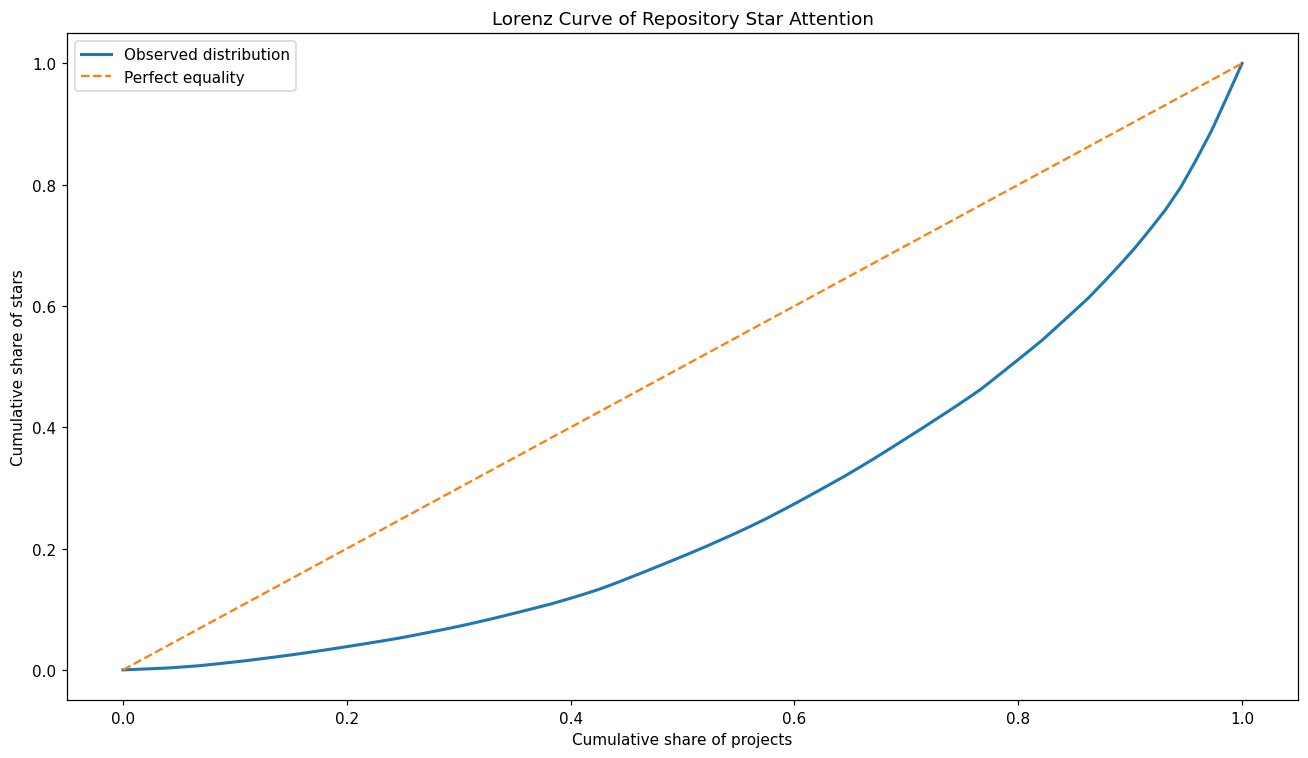

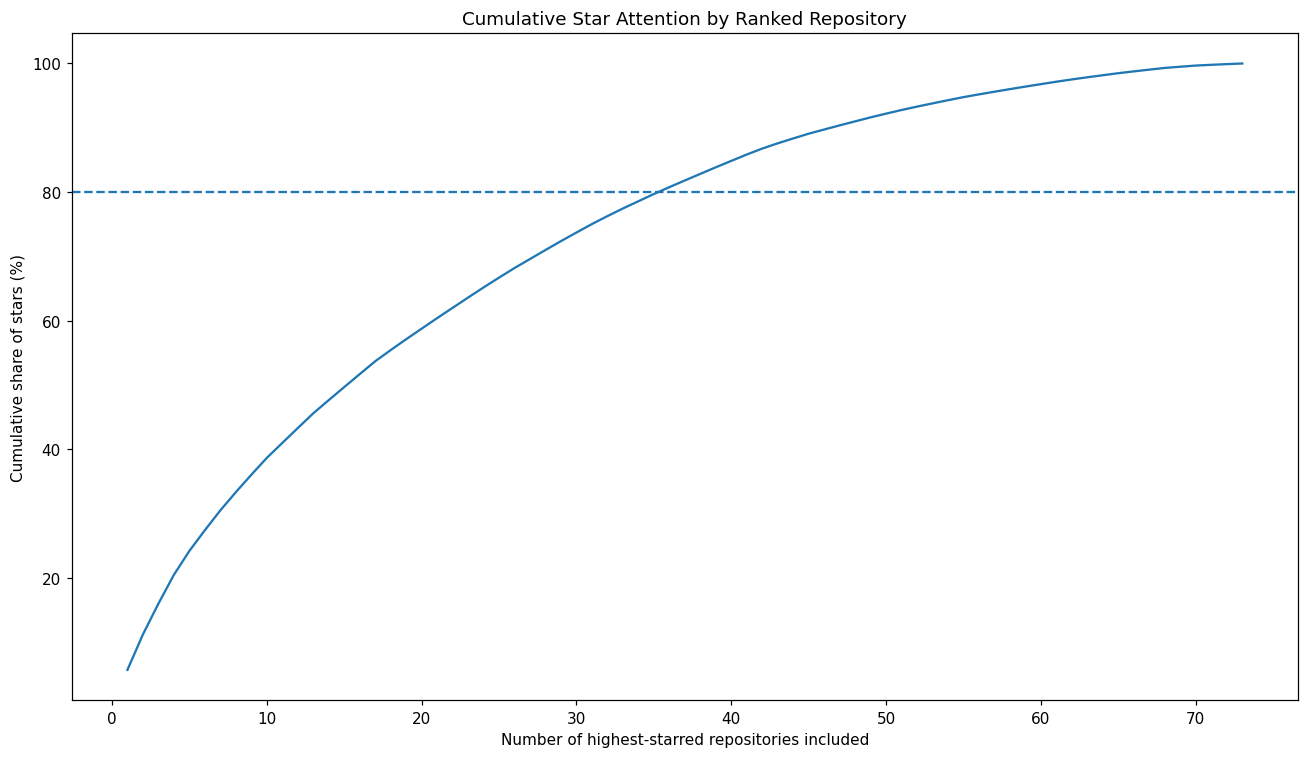


### Finding

The top 10 repositories account for **38.6%** of stars, while the top 20 account for **58.7%**. The corrected Gini coefficient is **0.451**.

### Interpretation

Repository attention is moderately concentrated: a relatively small group of major projects holds a substantial share of accumulated visibility.




In [18]:
def gini_coefficient(values):
    """Calculate the Gini coefficient for a non-negative one-dimensional array."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if np.any(values < 0):
        raise ValueError("Gini coefficient requires non-negative values.")
    if values.size == 0 or values.sum() == 0:
        return 0.0
    values = np.sort(values)
    n = values.size
    ranks = np.arange(1, n + 1)
    return (2 * np.sum(ranks * values) / (n * values.sum())) - ((n + 1) / n)


gini = gini_coefficient(df["stars"])
sorted_desc = df.sort_values("stars", ascending=False).reset_index(drop=True)
sorted_desc["cumulative_star_share"] = sorted_desc["stars"].cumsum() / sorted_desc["stars"].sum()

concentration = pd.DataFrame({
    "Group": ["Top project", "Top 5", "Top 10", "Top 20"],
    "Share of stars": [
        sorted_desc.head(1)["stars"].sum() / df["stars"].sum(),
        sorted_desc.head(5)["stars"].sum() / df["stars"].sum(),
        sorted_desc.head(10)["stars"].sum() / df["stars"].sum(),
        sorted_desc.head(20)["stars"].sum() / df["stars"].sum(),
    ]
})
display(concentration.style.format({"Share of stars": "{:.1%}"}))
print(f"Corrected Gini coefficient: {gini:.3f}")

# Lorenz curve: ascending order is essential.
stars_ascending = np.sort(df["stars"].to_numpy(dtype=float))
lorenz_y = np.insert(np.cumsum(stars_ascending) / stars_ascending.sum(), 0, 0)
lorenz_x = np.linspace(0, 1, len(lorenz_y))

fig, ax = plt.subplots()
ax.plot(lorenz_x, lorenz_y, linewidth=2, label="Observed distribution")
ax.plot([0, 1], [0, 1], linestyle="--", label="Perfect equality")
ax.set_title("Lorenz Curve of Repository Star Attention")
ax.set_xlabel("Cumulative share of projects")
ax.set_ylabel("Cumulative share of stars")
ax.legend()
plt.tight_layout()
plt.show()

# Pareto-style cumulative attention curve.
fig, ax = plt.subplots()
ax.plot(np.arange(1, len(sorted_desc) + 1), sorted_desc["cumulative_star_share"] * 100)
ax.axhline(80, linestyle="--")
ax.set_title("Cumulative Star Attention by Ranked Repository")
ax.set_xlabel("Number of highest-starred repositories included")
ax.set_ylabel("Cumulative share of stars (%)")
plt.tight_layout()
plt.show()

display(Markdown(f"""
### Finding

The top 10 repositories account for **{concentration.loc[concentration['Group'] == 'Top 10', 'Share of stars'].iloc[0]:.1%}** of stars, while the top 20 account for **{concentration.loc[concentration['Group'] == 'Top 20', 'Share of stars'].iloc[0]:.1%}**. The corrected Gini coefficient is **{gini:.3f}**.

### Interpretation

Repository attention is moderately concentrated: a relatively small group of major projects holds a substantial share of accumulated visibility.


"""))

## 6. Insight 3 - Project positioning: leaders, challengers, established influence, and niche projects

An age-based definition of “emerging” produced no useful segment because all projects in the snapshot are mature. This notebook instead uses relative positioning based on the dataset medians:

- **Major leaders:** high stars and high lifetime velocity.
- **High-velocity challengers:** below-median stars and above-median lifetime velocity.
- **Established influence:** high stars and below-median lifetime velocity.
- **Niche / steady:** below-median stars and below-median lifetime velocity.

This is a descriptive segmentation-not a claim about future growth.

,Position,Projects
0,Major leaders,33
1,Niche / steady,32
2,High-velocity challengers,4
3,Established influence,4


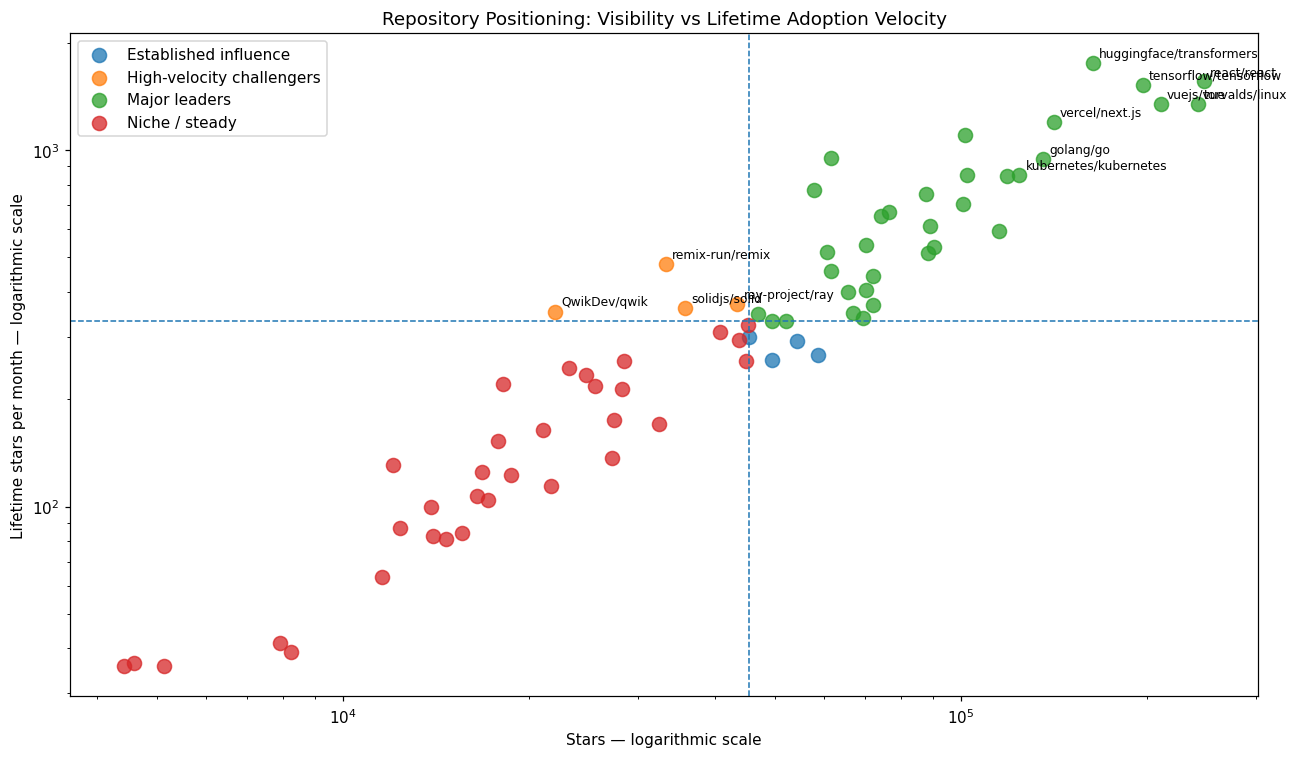

,full_name,language,stars,lifetime_star_velocity,forks,open_issues
5,remix-run/remix,TypeScript,33280,480.50,2790,65
29,ray-project/ray,Python,43446,370.40,7884,3478
9,solidjs/solid,TypeScript,35795,360.30,1086,29
8,QwikDev/qwik,TypeScript,22037,352.40,1395,161



### Finding

The high-velocity challenger segment contains **4 projects**: remix-run/remix, ray-project/ray, solidjs/solid, QwikDev/qwik.

### Interpretation

These repositories have not accumulated as many stars as the median project, but their lifetime star-acquisition velocity is above the dataset median. They merit attention as relatively fast-adopting projects within this sample.

### Limitation

Lifetime velocity is calculated from accumulated stars and project age. It does not measure recent monthly momentum and should not be used as a forecast.


In [19]:
median_stars = df["stars"].median()
median_velocity = df["lifetime_star_velocity"].median()

conditions = [
    (df["stars"] >= median_stars) & (df["lifetime_star_velocity"] >= median_velocity),
    (df["stars"] < median_stars) & (df["lifetime_star_velocity"] >= median_velocity),
    (df["stars"] >= median_stars) & (df["lifetime_star_velocity"] < median_velocity),
]
labels = ["Major leaders", "High-velocity challengers", "Established influence"]
df["project_position"] = np.select(conditions, labels, default="Niche / steady")

position_counts = (
    df["project_position"].value_counts()
      .rename_axis("Position")
      .reset_index(name="Projects")
)
display(position_counts)

fig, ax = plt.subplots()
for position, group in df.groupby("project_position"):
    ax.scatter(
        group["stars"],
        group["lifetime_star_velocity"],
        s=85,
        alpha=0.75,
        label=position,
    )

ax.axvline(median_stars, linestyle="--", linewidth=1)
ax.axhline(median_velocity, linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Repository Positioning: Visibility vs Lifetime Adoption Velocity")
ax.set_xlabel("Stars — logarithmic scale")
ax.set_ylabel("Lifetime stars per month — logarithmic scale")
ax.legend()

label_candidates = pd.concat([
    df.nlargest(8, "stars"),
    df[df["project_position"] == "High-velocity challengers"]
]).drop_duplicates("full_name")

for _, row in label_candidates.iterrows():
    ax.annotate(
        row["full_name"],
        (row["stars"], row["lifetime_star_velocity"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )

plt.tight_layout()
plt.show()

challengers = (
    df[df["project_position"] == "High-velocity challengers"]
      .sort_values("lifetime_star_velocity", ascending=False)
      [["full_name", "language", "stars", "lifetime_star_velocity", "forks", "open_issues"]]
)
display(challengers.round({"lifetime_star_velocity": 1}))

challenger_names = ", ".join(challengers["full_name"].tolist())
display(Markdown(f"""
### Finding

The high-velocity challenger segment contains **{len(challengers)} projects**: {challenger_names}.

### Interpretation

These repositories have not accumulated as many stars as the median project, but their lifetime star-acquisition velocity is above the dataset median. They merit attention as relatively fast-adopting projects within this sample.

### Limitation

Lifetime velocity is calculated from accumulated stars and project age. It does not measure recent monthly momentum and should not be used as a forecast.
"""))

## 7. Insight 4 - Community participation through fork intensity

Forks can indicate reuse, experimentation, customization, education, or contribution activity. To avoid rewarding popularity alone, the analysis compares forks per 1,000 stars.

A minimum threshold of 10,000 stars is used when ranking intensity so very small denominators do not dominate the results.

,full_name,language,stars,forks,forks_per_1k_stars
27,apache/spark,Scala,43783,29307,669.40
32,opencv/opencv,C++,90292,56953,630.80
36,python/cpython,Python,74160,35136,473.80
23,pandas-dev/pandas,Python,49418,20228,409.30
22,scikit-learn/scikit-learn,Python,66880,27257,407.60
33,pytorch/vision,Python,17849,7239,405.60
24,numpy/numpy,Python,32486,12613,388.30
11,django/django,Python,88350,34101,386.00
20,tensorflow/tensorflow,C++,196805,75851,385.40
12,rails/rails,Ruby,58675,22346,380.80


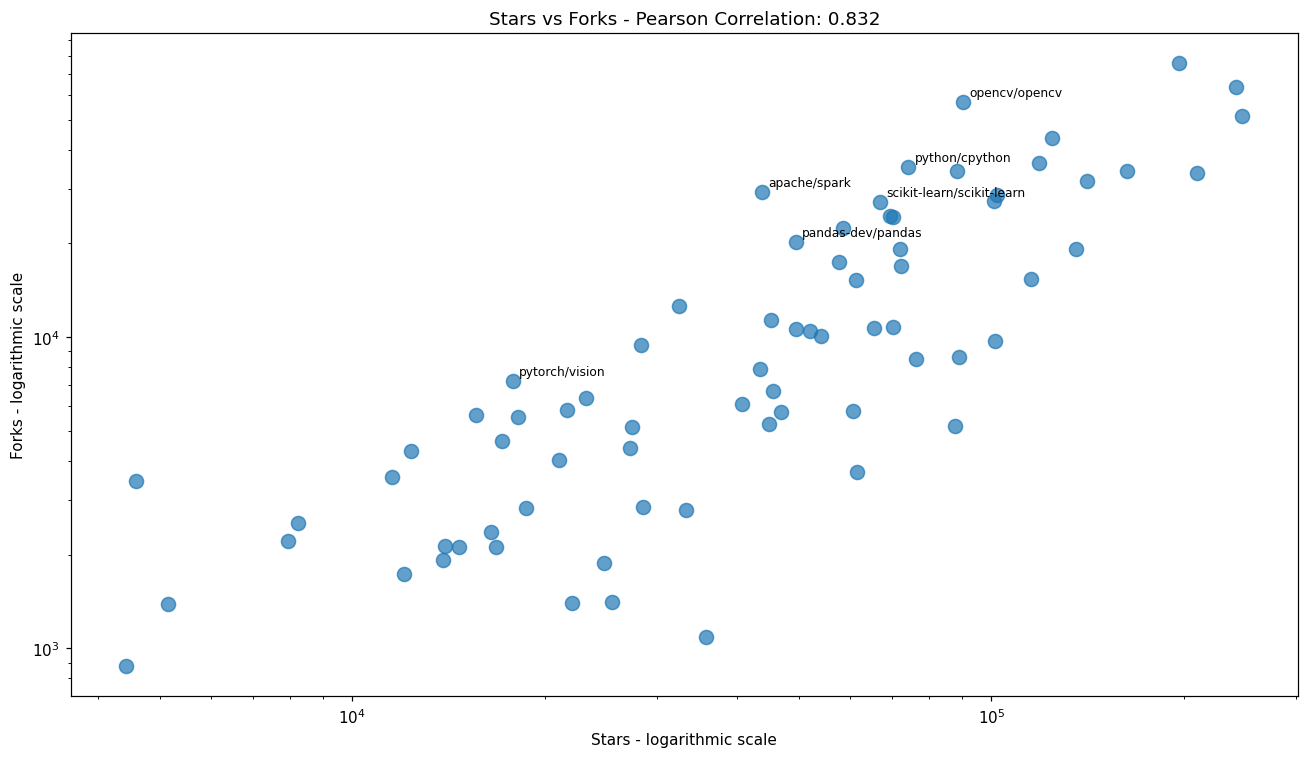


### Finding

Stars and forks have a strong positive relationship in this sample (**r = 0.832**), but fork intensity surfaces a different group of repositories than a simple star ranking.

### Interpretation

Projects with high forks per 1,000 stars appear to generate unusually high levels of reuse or technical participation relative to their visibility.




In [22]:
MIN_STARS_FOR_RATE_RANKING = 10_000
rate_eligible = df[df["stars"] >= MIN_STARS_FOR_RATE_RANKING].copy()

top_fork_intensity = (
    rate_eligible.nlargest(10, "forks_per_1k_stars")
    [["full_name", "language", "stars", "forks", "forks_per_1k_stars"]]
)
display(top_fork_intensity.round({"forks_per_1k_stars": 1}))

fork_corr = df["stars"].corr(df["forks"])

fig, ax = plt.subplots()
ax.scatter(df["stars"], df["forks"], s=85, alpha=0.7)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title(f"Stars vs Forks - Pearson Correlation: {fork_corr:.3f}")
ax.set_xlabel("Stars - logarithmic scale")
ax.set_ylabel("Forks - logarithmic scale")

for _, row in top_fork_intensity.head(6).iterrows():
    ax.annotate(
        row["full_name"],
        (row["stars"], row["forks"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )

plt.tight_layout()
plt.show()

display(Markdown(f"""
### Finding

Stars and forks have a strong positive relationship in this sample (**r = {fork_corr:.3f}**), but fork intensity surfaces a different group of repositories than a simple star ranking.

### Interpretation

Projects with high forks per 1,000 stars appear to generate unusually high levels of reuse or technical participation relative to their visibility.


"""))

## 8. Insight 5 - Maintenance workload and legacy influence

Open issues are normalized per 1,000 stars to identify repositories with unusually large issue backlogs relative to visibility. This is presented as a **potential maintenance-workload proxy**, not a quality score.

Repository inactivity is analyzed separately because a highly starred inactive repository can retain historical influence even when development has moved elsewhere.

,full_name,language,stars,open_issues,issues_per_1k_stars,activity_level
41,dotnet/runtime,C#,18143,7647,421.50,Very Active
34,statsmodels/statsmodels,Python,11552,2879,249.20,Very Active
21,pytorch/pytorch,Python,102181,18461,180.70,Very Active
40,swiftlang/swift,Swift,70217,9163,130.50,Very Active
36,python/cpython,Python,74160,9488,127.90,Very Active
69,saltstack/salt,Python,15598,1909,122.40,Very Active
38,rust-lang/rust,Rust,115198,12725,110.50,Very Active
50,hashicorp/nomad,Go,16777,1634,97.40,Very Active
70,pulumi/pulumi,Go,25526,2466,96.60,Very Active
28,dask/dask,Python,13880,1287,92.70,Very Active


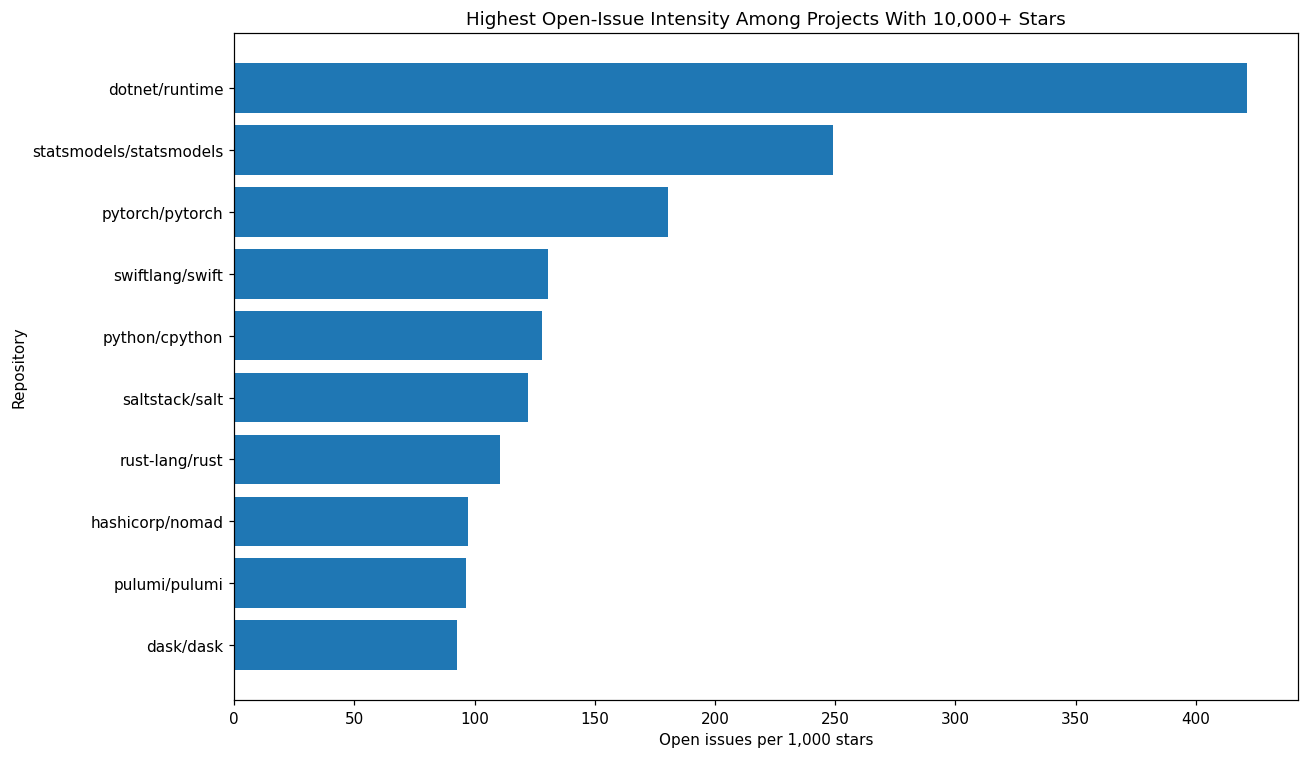

,full_name,language,stars,days_since_commit_clean,activity_level
1,vuejs/vue,TypeScript,210192,664.00,Abandoned
58,vuejs/vuex,JavaScript,28329,678.00,Abandoned


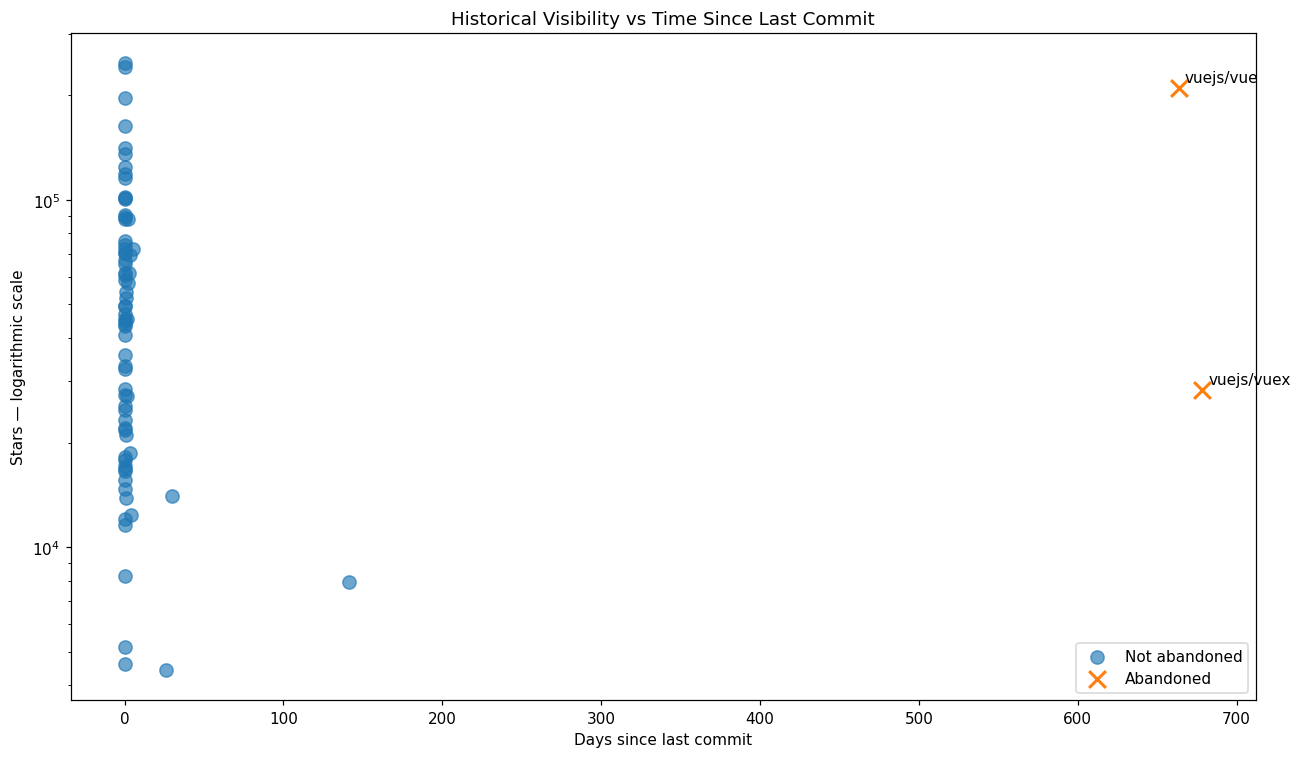


### Finding

Repositories classified as inactive or abandoned retain **238,521 stars**, representing **5.4%** of accumulated star attention in this sample.

### Interpretation

Popularity can persist after development slows or moves to a successor repository. Historical influence and current repository health are therefore different concepts.




In [24]:
top_issue_intensity = (
    rate_eligible.nlargest(10, "issues_per_1k_stars")
    [["full_name", "language", "stars", "open_issues", "issues_per_1k_stars", "activity_level"]]
)
display(top_issue_intensity.round({"issues_per_1k_stars": 1}))

plot_issue = top_issue_intensity.sort_values("issues_per_1k_stars")
fig, ax = plt.subplots()
ax.barh(plot_issue["full_name"], plot_issue["issues_per_1k_stars"])
ax.set_title("Highest Open-Issue Intensity Among Projects With 10,000+ Stars")
ax.set_xlabel("Open issues per 1,000 stars")
ax.set_ylabel("Repository")
plt.tight_layout()
plt.show()

legacy_projects = (
    df[df["is_abandoned"] | df["activity_level"].isin(["Inactive", "Abandoned"])]
      .sort_values("stars", ascending=False)
      [["full_name", "language", "stars", "days_since_commit_clean", "activity_level"]]
)
display(legacy_projects.round({"days_since_commit_clean": 0}))

fig, ax = plt.subplots()
active = df[~df["is_abandoned"]]
legacy = df[df["is_abandoned"]]
ax.scatter(active["days_since_commit_clean"], active["stars"], s=75, alpha=0.65, label="Not abandoned")
if not legacy.empty:
    ax.scatter(legacy["days_since_commit_clean"], legacy["stars"], s=120, marker="x", linewidths=2, label="Abandoned")
    for _, row in legacy.iterrows():
        ax.annotate(row["full_name"], (row["days_since_commit_clean"], row["stars"]), xytext=(4, 4), textcoords="offset points")
ax.set_yscale("log")
ax.set_title("Historical Visibility vs Time Since Last Commit")
ax.set_xlabel("Days since last commit")
ax.set_ylabel("Stars — logarithmic scale")
ax.legend()
plt.tight_layout()
plt.show()

legacy_stars = legacy_projects["stars"].sum()
legacy_share = legacy_stars / df["stars"].sum() if len(df) else np.nan

display(Markdown(f"""
### Finding

Repositories classified as inactive or abandoned retain **{legacy_stars:,.0f} stars**, representing **{legacy_share:.1%}** of accumulated star attention in this sample.

### Interpretation

Popularity can persist after development slows or moves to a successor repository. Historical influence and current repository health are therefore different concepts.


"""))

## 9. Insight 6 - Project age and metric relationships

This section tests whether older projects automatically accumulate more popularity and summarizes associations among the main variables.

Correlations are descriptive. They do not establish causality, and some relationships are mathematically linked—for example, lifetime star velocity contains stars in its calculation.

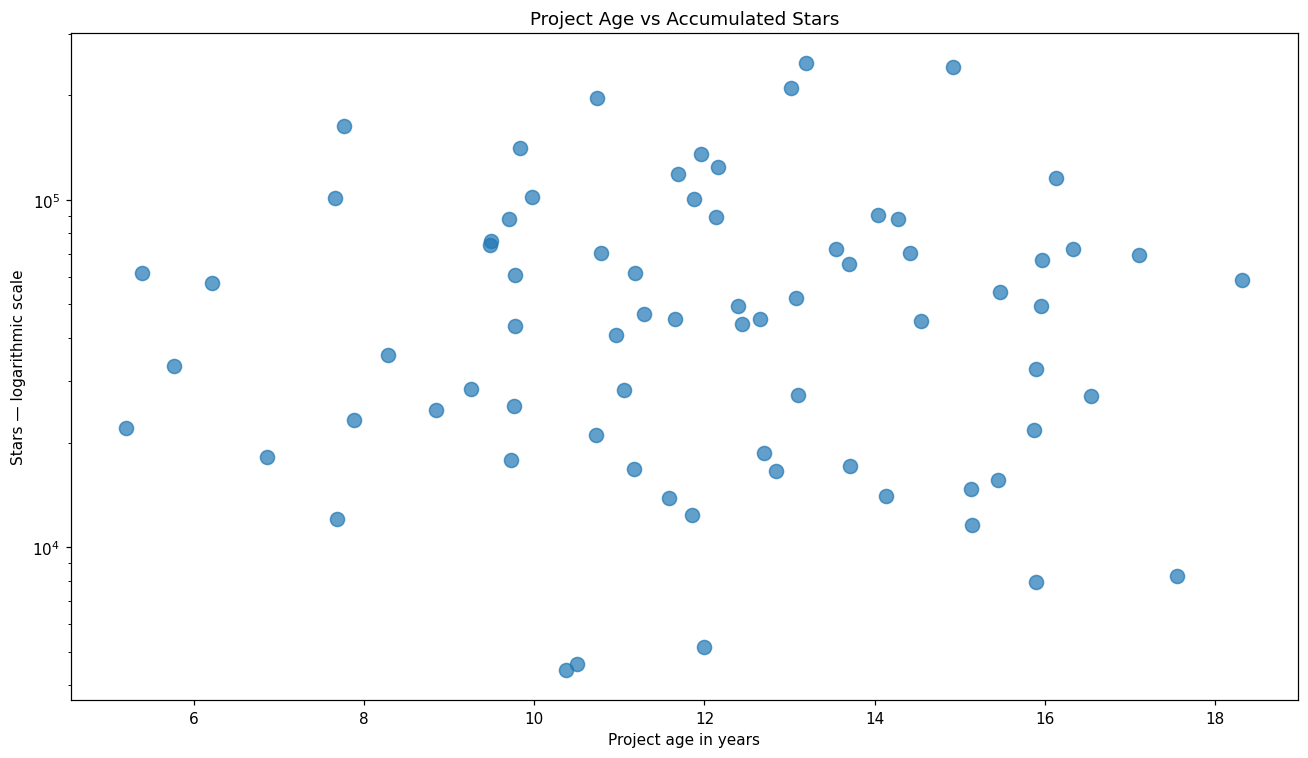

,Relationship,Correlation
0,Age vs stars — Pearson,0.03
1,Age vs stars — Spearman,0.00
2,Stars vs forks — Pearson,0.83
3,Stars vs open issues — Pearson,0.23


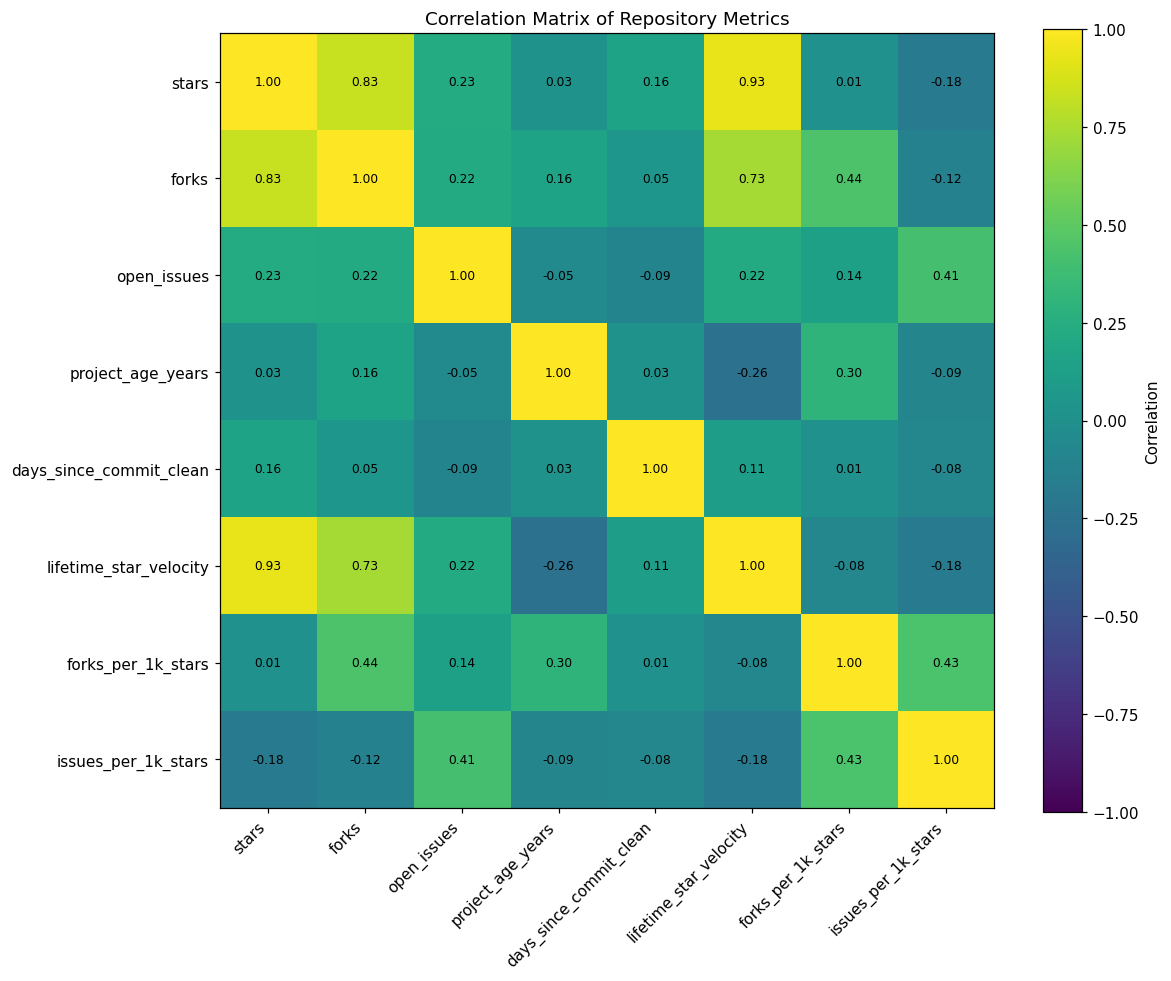


### Finding

Project age has almost no relationship with accumulated stars in this snapshot: Pearson **r = 0.027** and Spearman **ρ = 0.003**.

### Interpretation

Longevity alone does not explain repository visibility. Ecosystem relevance, project purpose, developer adoption, and network effects likely matter more than age by itself.




In [26]:
age_star_pearson = df["project_age_years"].corr(df["stars"], method="pearson")
age_star_spearman = df["project_age_years"].corr(df["stars"], method="spearman")

fig, ax = plt.subplots()
ax.scatter(df["project_age_years"], df["stars"], s=85, alpha=0.7)
ax.set_yscale("log")
ax.set_title("Project Age vs Accumulated Stars")
ax.set_xlabel("Project age in years")
ax.set_ylabel("Stars — logarithmic scale")
plt.tight_layout()
plt.show()

relationship_summary = pd.DataFrame({
    "Relationship": [
        "Age vs stars — Pearson",
        "Age vs stars — Spearman",
        "Stars vs forks — Pearson",
        "Stars vs open issues — Pearson",
    ],
    "Correlation": [
        age_star_pearson,
        age_star_spearman,
        df["stars"].corr(df["forks"]),
        df["stars"].corr(df["open_issues"]),
    ]
})
display(relationship_summary.round(3))

corr_columns = [
    "stars", "forks", "open_issues", "project_age_years",
    "days_since_commit_clean", "lifetime_star_velocity",
    "forks_per_1k_stars", "issues_per_1k_stars"
]
corr_matrix = df[corr_columns].corr()

fig, ax = plt.subplots(figsize=(11, 9))
image = ax.imshow(corr_matrix.to_numpy(), vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_columns)), labels=corr_columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_columns)), labels=corr_columns)
for row_index in range(len(corr_columns)):
    for column_index in range(len(corr_columns)):
        ax.text(column_index, row_index, f"{corr_matrix.iloc[row_index, column_index]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Correlation Matrix of Repository Metrics")
fig.colorbar(image, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()

display(Markdown(f"""
### Finding

Project age has almost no relationship with accumulated stars in this snapshot: Pearson **r = {age_star_pearson:.3f}** and Spearman **ρ = {age_star_spearman:.3f}**.

### Interpretation

Longevity alone does not explain repository visibility. Ecosystem relevance, project purpose, developer adoption, and network effects likely matter more than age by itself.


"""))

## 10. Executive findings

In [10]:
top_project = df.nlargest(1, "stars").iloc[0]
top_language = language_summary.iloc[0]
top_fork_project = top_fork_intensity.iloc[0]
top_issue_project = top_issue_intensity.iloc[0]
top10_share = concentration.loc[concentration["Group"] == "Top 10", "Share of stars"].iloc[0]

executive_summary = f"""
### What the analysis shows

1. **Language leadership depends on the metric.** {top_language['language']} has the largest total star footprint and the broadest project representation, but median performance reveals a different view of typical repository visibility.
2. **Attention is moderately concentrated.** The top 10 repositories hold {top10_share:.1%} of stars, and the corrected Gini coefficient is {gini:.3f}.
3. **Visibility and adoption velocity are not the same.** Four below-median-star projects qualify as high-velocity challengers: {challenger_names}.
4. **Fork intensity adds information beyond stars.** {top_fork_project['full_name']} has the highest forks-per-1,000-stars ratio among projects with at least 10,000 stars.
5. **Issue intensity varies widely.** {top_issue_project['full_name']} has the largest open-issue workload relative to stars among projects meeting the same threshold.
6. **Historical popularity can outlive active development.** Inactive or abandoned repositories still retain {legacy_stars:,.0f} stars.
7. **Age is not a meaningful popularity explanation in this sample.** The correlation between age and stars is approximately zero.

### Central conclusion

> **GitHub stars are useful indicators of accumulated visibility, but they are insufficient for measuring current momentum, community health, maintenance sustainability, or software quality.**
"""
display(Markdown(executive_summary))


### What the analysis shows

1. **Language leadership depends on the metric.** Python has the largest total star footprint and the broadest project representation, but median performance reveals a different view of typical repository visibility.
2. **Attention is moderately concentrated.** The top 10 repositories hold 38.6% of stars, and the corrected Gini coefficient is 0.451.
3. **Visibility and adoption velocity are not the same.** Four below-median-star projects qualify as high-velocity challengers: remix-run/remix, ray-project/ray, solidjs/solid, QwikDev/qwik.
4. **Fork intensity adds information beyond stars.** apache/spark has the highest forks-per-1,000-stars ratio among projects with at least 10,000 stars.
5. **Issue intensity varies widely.** dotnet/runtime has the largest open-issue workload relative to stars among projects meeting the same threshold.
6. **Historical popularity can outlive active development.** Inactive or abandoned repositories still retain 238,521 stars.
7. **Age is not a meaningful popularity explanation in this sample.** The correlation between age and stars is approximately zero.

### Central conclusion

> **GitHub stars are useful indicators of accumulated visibility, but they are insufficient for measuring current momentum, community health, maintenance sustainability, or software quality.**


## 11. Methodological limitations

- **Snapshot limitation:** The data represents one collection date rather than a time series.
- **Selection limitation:** The 73 repositories are not a random or complete sample of GitHub.
- **Stars:** Stars measure accumulated attention, not current adoption, quality, or production usage.
- **Lifetime velocity:** Stars divided by age is a historical average and can hide recent acceleration or decline.
- **Forks:** Fork counts do not distinguish inactive forks, education, experimentation, contributions, or production use.
- **Open issues:** Issue counts are affected by repository policy, project complexity, feature requests, and external tracking systems.
- **Activity classification:** Repository-level activity can be misleading when development moves to another repository or branch.
- **Language comparisons:** Uneven sample sizes can make languages with very few repositories appear unusually strong or weak.

The findings should therefore be framed as **descriptive signals within the selected dataset**, not universal rankings of open-source quality.

## 12. Recommended next iteration

The most valuable improvement is to collect repeated snapshots—monthly or weekly—and add operational community metrics:

- Stars gained in the last 30 and 90 days.
- Forks gained in the last 30 and 90 days.
- Commits during the last 90 days.
- Active contributor count.
- Pull requests opened, merged, and closed.
- Issue closure rate and median issue age.
- Release frequency and latest release date.
- Archived status and license.
- Project topic or category.

These additions would support true momentum, responsiveness, contributor health, and maintenance-sustainability analysis.

## 13. Optional export of the analysis-ready dataset

In [11]:
# Set this to True when you want to save the corrected analytical fields.
EXPORT_ANALYSIS_DATA = False

if EXPORT_ANALYSIS_DATA:
    output_path = Path("data/processed/github_projects_analysis_ready.csv")
    output_path.parent.mkdir(parents=True, exist_ok=True)

    export_columns = [
        "full_name", "name", "url", "description", "language",
        "stars", "forks", "open_issues", "created_at", "last_commit_at",
        "data_collected_at", "days_active_clean", "project_age_years",
        "days_since_commit_clean", "lifetime_star_velocity",
        "forks_per_1k_stars", "issues_per_1k_stars",
        "is_abandoned", "activity_level", "project_position"
    ]
    df[export_columns].to_csv(output_path, index=False)
    print(f"Saved analysis-ready data to: {output_path.resolve()}")
else:
    print("Export skipped. Set EXPORT_ANALYSIS_DATA = True to save the analysis-ready CSV.")

Export skipped. Set EXPORT_ANALYSIS_DATA = True to save the analysis-ready CSV.
